# Análisis Exploratorio de Datos (EDA) — Incendios Forestales en Ecuador
Este notebook realiza un análisis exploratorio completo del conjunto de datos meteorológicos y satelitales consolidado en SQL Server. El objetivo es identificar patrones estacionales, correlaciones climáticas y hallazgos interesantes para justificar y guiar el entrenamiento de modelos de Machine Learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

# Estilo de las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Conexión y Carga de Datos
Consumimos la vista unificada `vw_DatosUnificados` en SQL Server para obtener el conjunto de datos completo e integrado temporal y espacialmente.

In [2]:
CONN_STR = "mssql+pyodbc://LUIS/IncendiosForestalesEC?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
engine = create_engine(CONN_STR)

# Extraemos toda la data de la vista unificada
df = pd.read_sql("SELECT * FROM vw_DatosUnificados ORDER BY fecha, id_ciudad", con=engine)
df['fecha'] = pd.to_datetime(df['fecha'])
df['mes_nombre'] = df['fecha'].dt.strftime('%B')
df['mes'] = df['fecha'].dt.month

print(f"Registros cargados: {len(df)}")
df.head()

Registros cargados: 21100


,id_clima,id_ciudad,ciudad_nombre,ciudad_region,ciudad_latitud,ciudad_longitud,altitud_msnm,fecha,velocidad_viento,direccion_viento,...,humedad_relativa,precipitacion,ndvi,evi,conteo_incendios,max_brightness,max_frp,incendio_binario,mes_nombre,mes
0,221784,1,Quito,Sierra,-0.1807,-78.4678,2850.0,2012-01-01,2.56,292.7,...,83.44,1.27,0.5241,0.2,0,0.0,0.0,0,January,1
1,216509,2,Guayaquil,Costa,-2.1894,-79.8890,4.0,2012-01-01,4.79,239.9,...,59.87,10.36,0.1147,0.2,0,0.0,0.0,0,January,1
2,227059,3,Riobamba,Sierra,-1.6731,-78.6530,2754.0,2012-01-01,1.83,76.1,...,84.57,17.50,0.1020,0.2,0,0.0,0.0,0,January,1
3,211234,4,Cuenca,Sierra,-2.9001,-79.0060,2560.0,2012-01-01,2.70,81.4,...,87.58,36.56,0.2524,0.2,0,0.0,0.0,0,January,1
4,221785,1,Quito,Sierra,-0.1807,-78.4678,2850.0,2012-01-02,3.23,279.4,...,83.69,6.79,0.5241,0.2,6,324.7,16.8,1,January,1


## 2. Análisis Estacional Climático
Analicemos cuáles son los meses con menores lluvias y mayores temperaturas para entender la estacionalidad climática en el país.

In [3]:
# Agrupamos por mes para ver el comportamiento promedio del clima
df_mensual = df.groupby('mes').agg({
    'temperatura_media': 'mean',
    'temperatura_max': 'mean',
    'precipitacion': 'mean',
    'humedad_relativa': 'mean',
    'velocidad_viento': 'mean',
    'conteo_incendios': 'sum'
}).reset_index()

meses_es = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
df_mensual['nombre_mes'] = meses_es
df_mensual

,mes,temperatura_media,temperatura_max,precipitacion,humedad_relativa,velocidad_viento,conteo_incendios,nombre_mes
0,1,17.552258,22.891688,4.679339,82.512763,2.766866,5117,Ene
1,2,17.439469,22.191592,5.815914,85.749004,2.547789,6398,Feb
2,3,17.379548,21.928952,5.875978,86.521941,2.449742,2197,Mar
3,4,17.478100,22.436944,5.042044,85.140706,2.588194,1657,Abr
4,5,17.353806,22.733086,3.969016,83.858161,2.736726,1028,May
5,6,16.781273,22.743122,3.142262,80.659267,3.247616,1452,Jun
6,7,16.686094,23.262264,1.694677,77.273013,3.624747,2346,Jul
7,8,16.931907,23.961181,1.431129,74.552079,3.583808,5101,Ago
8,9,17.424476,24.620262,1.269732,73.234250,3.467411,9018,Sep
9,10,17.692114,24.307840,2.520985,75.956619,3.058445,7255,Oct


### Gráfica 2.1: Relación entre Temperatura Máxima y Precipitación
Visualicemos cómo interactúan la escasez de lluvias con las temperaturas más altas a lo largo del año.

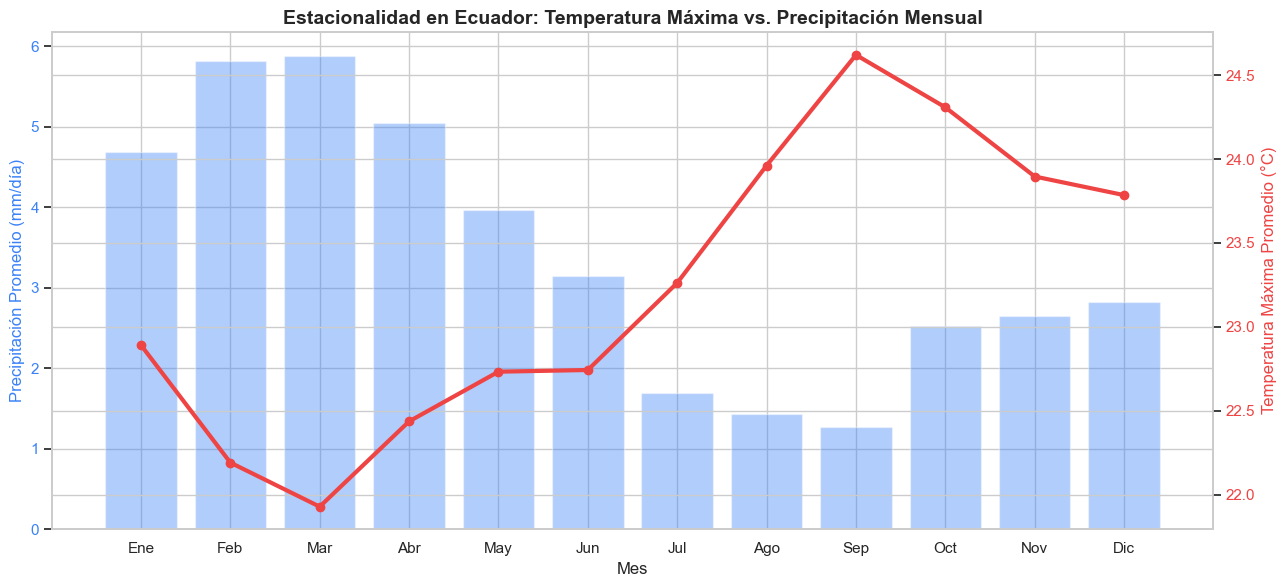

In [4]:
fig, ax1 = plt.subplots(figsize=(13, 6))

# Barra para precipitación
color_prec = '#3b82f6'
ax1.set_xlabel('Mes')
ax1.set_ylabel('Precipitación Promedio (mm/día)', color=color_prec)
bars = ax1.bar(df_mensual['nombre_mes'], df_mensual['precipitacion'], color=color_prec, alpha=0.4, label='Precipitación')
ax1.tick_params(axis='y', labelcolor=color_prec)

# Línea para temperatura máxima
ax2 = ax1.twinx()
color_temp = '#ef4444'
ax2.set_ylabel('Temperatura Máxima Promedio (°C)', color=color_temp)
line = ax2.plot(df_mensual['nombre_mes'], df_mensual['temperatura_max'], color=color_temp, linewidth=3, marker='o', label='Temp. Máx')
ax2.tick_params(axis='y', labelcolor=color_temp)

plt.title('Estacionalidad en Ecuador: Temperatura Máxima vs. Precipitación Mensual', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

**Hallazgo interesante 1:** Los meses de **junio a septiembre** marcan un descenso drástico en la precipitación (estación seca en la Sierra) y un aumento en las temperaturas máximas promedio. En noviembre y diciembre se registra el pico de sequedad acumulada antes del retorno de las lluvias invernales.

## 3. Comportamiento Geográfico de los Incendios
Veamos qué ciudades o áreas de influencia concentran el mayor número de incendios históricos y cómo difieren sus perfiles de altitud.

In [5]:
# Extraemos información estadística de incendios por ciudad
query_ciudad = """
    SELECT c.nombre AS Ciudad, c.region AS Region, c.altitud_msnm AS Altitud,
           COUNT(i.id_incendio) AS Total_Detecciones,
           AVG(i.confianza) AS Confianza_Promedio,
           AVG(i.frp) AS FRP_Promedio
    FROM Ciudades c
    LEFT JOIN Incendios i ON c.id_ciudad = i.id_ciudad
    GROUP BY c.nombre, c.region, c.altitud_msnm
    ORDER BY Total_Detecciones DESC
"""
df_ciudades = pd.read_sql(query_ciudad, con=engine)
df_ciudades

,Ciudad,Region,Altitud,Total_Detecciones,Confianza_Promedio,FRP_Promedio
0,Guayaquil,Costa,4.0,26054,64,23.715360
1,Quito,Sierra,2850.0,21568,66,36.377995
2,Cuenca,Sierra,2560.0,17487,63,26.799262
3,Riobamba,Sierra,2754.0,7423,69,54.692874


### Gráfica 3.1: Detecciones de Incendios por Área de Influencia y Región
Visualicemos la distribución espacial del volumen de fuegos detectados.

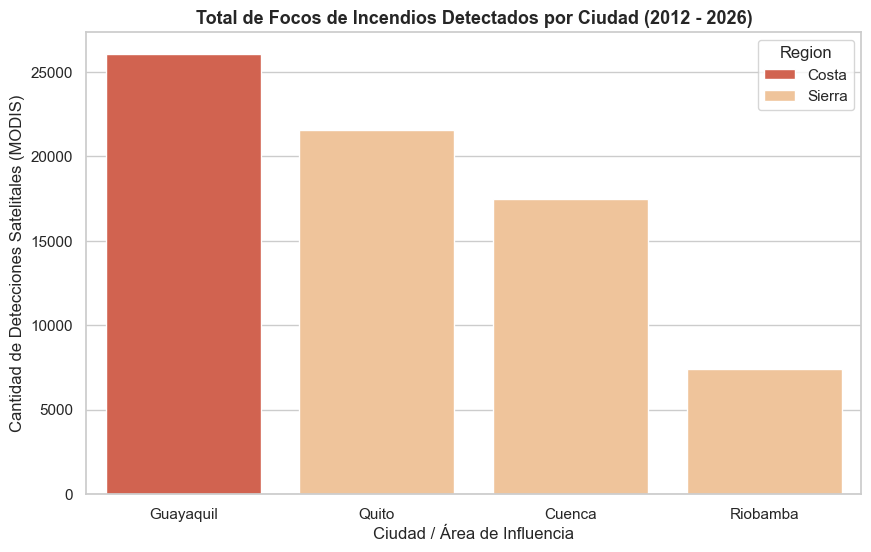

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_ciudades, x='Ciudad', y='Total_Detecciones', hue='Region', palette='OrRd_r')
plt.title('Total de Focos de Incendios Detectados por Ciudad (2012 - 2026)', fontsize=13, fontweight='bold')
plt.xlabel('Ciudad / Área de Influencia')
plt.ylabel('Cantidad de Detecciones Satelitales (MODIS)')
plt.show()

**Hallazgo interesante 2:** **Guayaquil (Región Costa)** presenta el mayor volumen acumulado de focos térmicos. Esto se debe a las quemas agrícolas de rastrojo combinadas con temperaturas elevadas del litoral. Sin embargo, las provincias de la **Sierra (Quito y Cuenca)** presentan riesgos severos debido a la topografía montañosa que acelera la propagación del viento.

## 4. Análisis de Correlación Climática e Incendios
¿Qué variables climáticas están más fuertemente correlacionadas con la presencia de incendios? Analicemos la correlación lineal.

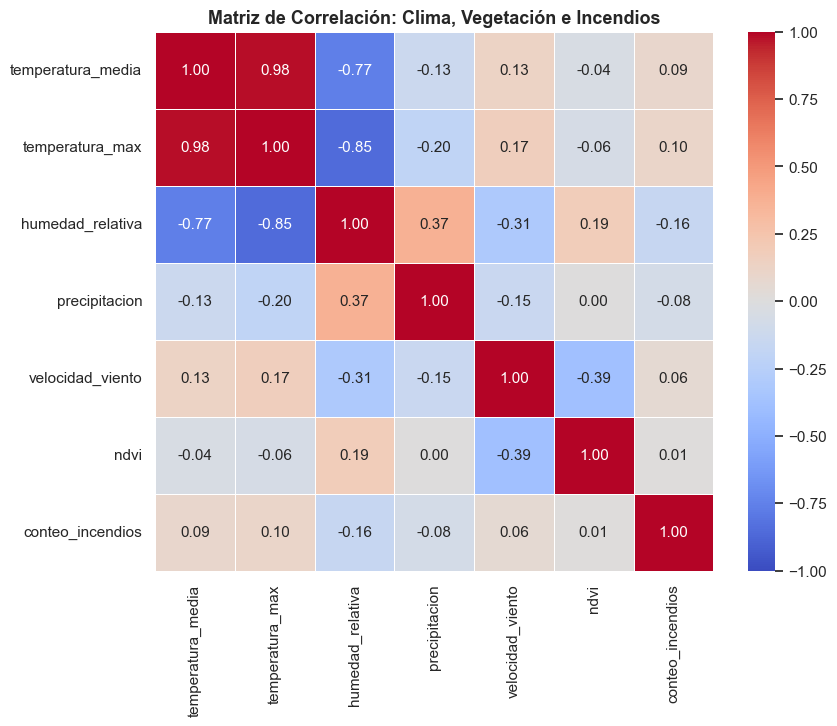

In [7]:
# Seleccionamos las variables climáticas principales
vars_correlacion = ['temperatura_media', 'temperatura_max', 'humedad_relativa', 
                     'precipitacion', 'velocidad_viento', 'ndvi', 'conteo_incendios']

corr_matrix = df[vars_correlacion].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación: Clima, Vegetación e Incendios', fontsize=13, fontweight='bold')
plt.show()

**Hallazgo interesante 3 (Correlaciones Clave):**
1. **Humedad Relativa vs. Incendios (Correlación Negativa)**: A menor humedad en el ambiente, mayor es la presencia de incendios.
2. **Temperatura Máxima vs. Incendios (Correlación Positiva)**: El calor extremo actúa como catalizador inicial.
3. **NDVI vs. Incendios**: El índice de vegetación tiene una correlación negativa sutil; a menor cobertura vegetal viva (NDVI bajo / vegetación seca), el terreno es más propicio a arder.

## 5. El Factor de la Vegetación: Análisis de NDVI
Analicemos cómo varía el NDVI (Índice de Diferencia Normalizada de Vegetación) mensual en la Sierra (Quito/Cuenca) en comparación con el número de fuegos.

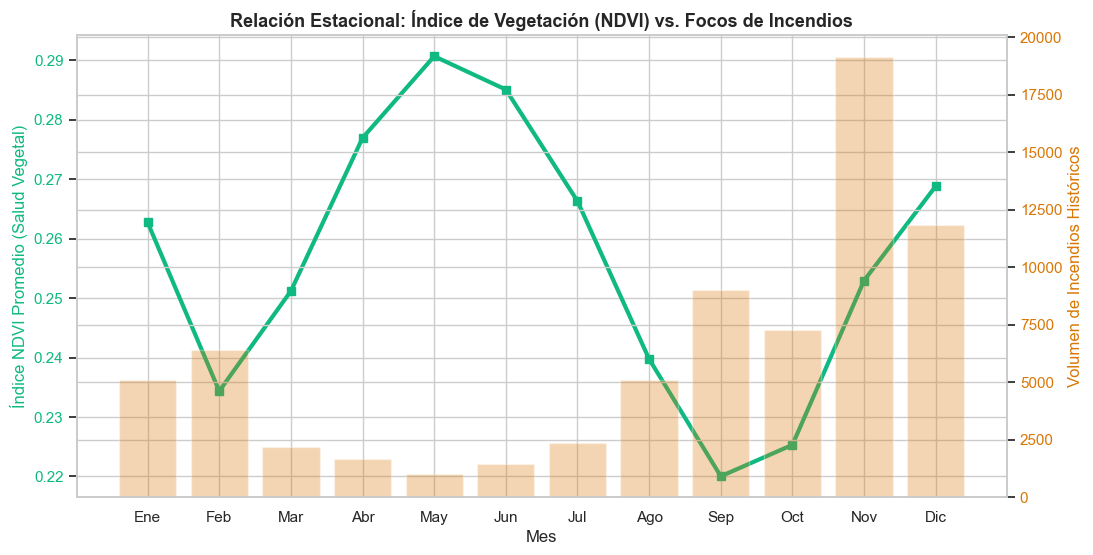

In [8]:
df_ndvi_mensual = df.groupby('mes').agg({
    'ndvi': 'mean',
    'conteo_incendios': 'sum'
}).reset_index()
df_ndvi_mensual['nombre_mes'] = meses_es

fig, ax1 = plt.subplots(figsize=(12, 6))

color_ndvi = '#10b981'
ax1.set_xlabel('Mes')
ax1.set_ylabel('Índice NDVI Promedio (Salud Vegetal)', color=color_ndvi)
ax1.plot(df_ndvi_mensual['nombre_mes'], df_ndvi_mensual['ndvi'], color=color_ndvi, linewidth=3, marker='s', label='NDVI')
ax1.tick_params(axis='y', labelcolor=color_ndvi)

ax2 = ax1.twinx()
color_fires = '#d97706'
ax2.set_ylabel('Volumen de Incendios Históricos', color=color_fires)
ax2.bar(df_ndvi_mensual['nombre_mes'], df_ndvi_mensual['conteo_incendios'], color=color_fires, alpha=0.3, label='Incendios')
ax2.tick_params(axis='y', labelcolor=color_fires)

plt.title('Relación Estacional: Índice de Vegetación (NDVI) vs. Focos de Incendios', fontsize=13, fontweight='bold')
plt.show()

**Hallazgo interesante 4:** Durante el verano e inicio del otoño (julio a septiembre), el NDVI desciende notablemente. El suelo pierde humedad y la vegetación se seca (se convierte en combustible fino). Este fenómeno precede y coincide directamente con el estallido de la temporada crítica de incendios (septiembre - noviembre).